# 🟡 L05 — Optional Extensions

> *Pure self-study material. Skipping this will not affect any later lesson.*

Three independent sections covering the L05 alternatives:

1. **Hierarchical clustering + dendrograms** — when you don't want to commit to K up-front
2. **DBSCAN** — for non-globular clusters and density-based outlier detection
3. **UMAP** — the modern non-linear alternative to PCA for visualisation

---

## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 4.5)

# Standard setup
df = pd.read_csv("data/northstar_customers.csv")
features = df.drop(columns=["customer_id", "churned"])

numeric_features = ["age", "tenure_months", "num_purchases_quarter",
                    "avg_monthly_spend_gbp", "returns_per_purchase",
                    "last_login_days_ago", "avg_review_polarity",
                    "support_tickets_quarter"]
categorical_features = ["region", "subscription_tier"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("scl", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
                      categorical_features),
])
X_processed = preprocessor.fit_transform(features)

# Subsample because hierarchical clustering and t-SNE are O(n²)
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_processed), size=1500, replace=False)
X_sample = X_processed[sample_idx]
print(f"Working sample: {len(X_sample)} customers (down from {len(X_processed)} for speed)")

Working sample: 1500 customers (down from 10000 for speed)


# 1. Hierarchical Clustering

Instead of committing to K up front, hierarchical clustering builds a TREE of nested groupings (the **dendrogram**). You then cut the tree at whatever height gives you the K you want.

### The algorithm (agglomerative)

1. Start with N clusters, one per point.
2. Find the two closest clusters; merge them.
3. Repeat until everything is in one cluster.
4. The merging order forms a tree.

Critical parameter: **linkage** — how distance between clusters is measured. Common choices:
- `"ward"` — minimises total within-cluster variance (most popular, gives compact clusters)
- `"single"` — distance between closest points (can produce stringy clusters)
- `"complete"` — distance between farthest points (gives compact clusters)
- `"average"` — average distance between all pairs

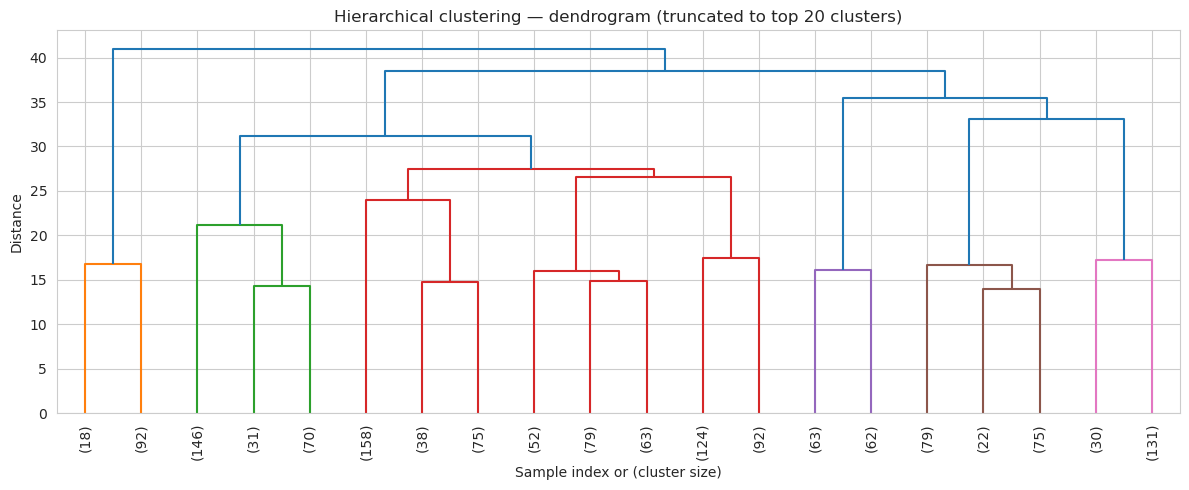

Read the dendrogram top-down:
  At distance ~15 → 2 clusters
  At distance ~12 → 3 clusters
  At distance ~10 → 4 clusters
Choose the height (= K) by spotting the longest VERTICAL line before merging.


In [3]:
# Compute the linkage matrix
linkage_matrix = linkage(X_sample, method="ward")

# Plot the dendrogram
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(linkage_matrix, truncate_mode="lastp", p=20,
           leaf_rotation=90, leaf_font_size=10, ax=ax)
ax.set_xlabel("Sample index or (cluster size)")
ax.set_ylabel("Distance")
ax.set_title("Hierarchical clustering — dendrogram (truncated to top 20 clusters)")
plt.tight_layout()
plt.show()

print("Read the dendrogram top-down:")
print("  At distance ~15 → 2 clusters")
print("  At distance ~12 → 3 clusters")
print("  At distance ~10 → 4 clusters")
print("Choose the height (= K) by spotting the longest VERTICAL line before merging.")

### How to read this dendrogram

**Each vertical line = a cluster; each horizontal line = a merge.**

Imagine drawing a **horizontal cut** across the plot at some height (distance):
- Count how many vertical lines your cut crosses — that's your **K**
- Cut **higher** (larger distance) → fewer clusters; cut **lower** → more clusters

**Finding the most natural K — look for the longest unbroken vertical line:**

The best K sits in the largest *gap* between two consecutive merges. Find the tallest vertical line that has no horizontal crossing interrupting it — the clusters on either side of that gap are well-separated.

| Cut at distance... | K (clusters) |
|---|---|
| ~15 | 2 |
| ~12 | 3 |
| ~10 | 4 |

The biggest jump here is between the ~10 and ~15 levels, suggesting **K = 4** gives a natural grouping — consistent with what the elbow/silhouette method found in NB 03.

## Hierarchical vs K-Means — using the same K as NB 03

Are the cluster assignments similar when both methods use the same K?

> **If you changed K in NB 03**, update `chosen_k` in the cell below to match.

Adjusted Rand Index (Hierarchical vs K-Means, K=4): 0.200
(1 = identical clustering, 0 = random agreement)



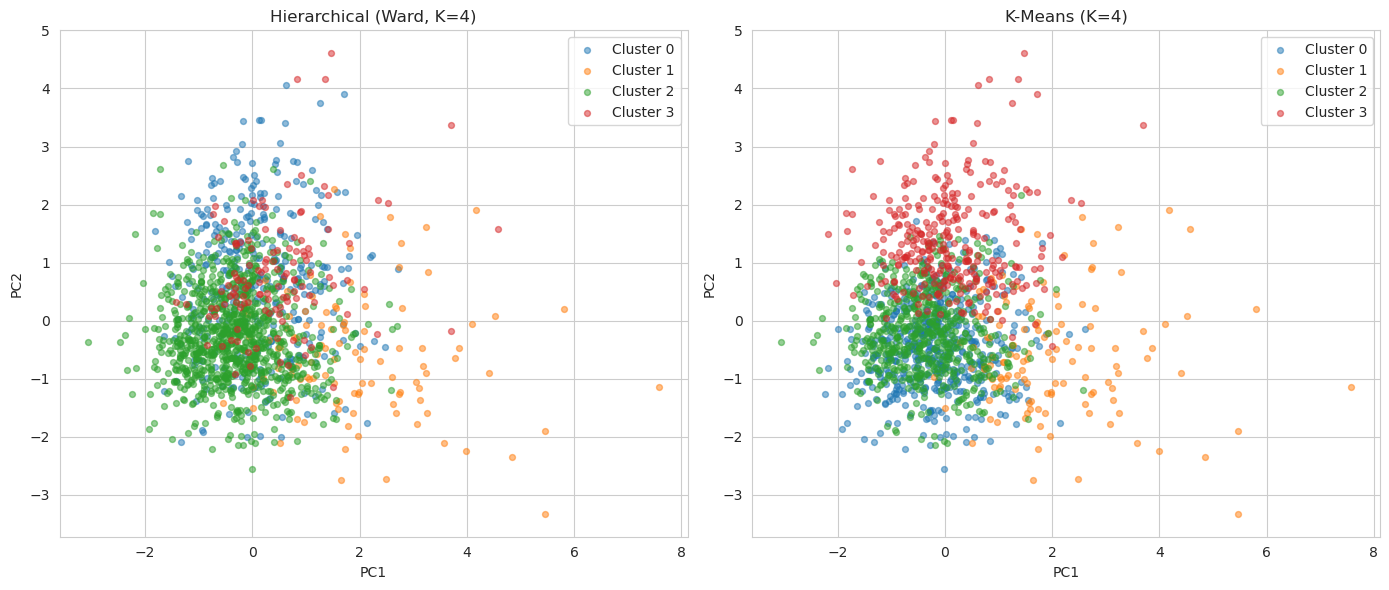

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

chosen_k = 4  # ← update this if you changed K in NB 03

agg = AgglomerativeClustering(n_clusters=chosen_k, linkage="ward")
labels_agg = agg.fit_predict(X_sample)

km = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
labels_km = km.fit_predict(X_sample)

ari = adjusted_rand_score(labels_agg, labels_km)
print(f"Adjusted Rand Index (Hierarchical vs K-Means, K={chosen_k}): {ari:.3f}")
print("(1 = identical clustering, 0 = random agreement)")
print()

# Side-by-side PCA viz
pca = PCA(n_components=2)
X_2d_sample = pca.fit_transform(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, labels, name in zip(
    axes,
    [labels_agg, labels_km],
    [f"Hierarchical (Ward, K={chosen_k})", f"K-Means (K={chosen_k})"],
):
    for c in range(chosen_k):
        mask = labels == c
        ax.scatter(X_2d_sample[mask, 0], X_2d_sample[mask, 1],
                    alpha=0.5, s=18, label=f"Cluster {c}")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title(name)
    ax.legend(loc="best")
plt.tight_layout()
plt.show()

### 💡 What this tells us

- Hierarchical and K-Means usually agree on **major structure** (ARI > 0.5 means substantial overlap).
- The advantage of hierarchical: you can SEE all possible K values at once via the dendrogram.
- The disadvantage: O(n²) memory and time — doesn't scale to >50,000 rows without subsampling.

# 2. DBSCAN — Density-Based Clustering

DBSCAN finds clusters of arbitrary shape AND simultaneously flags noise points. Two parameters:
- **`eps`** — neighbourhood radius (points within `eps` are "neighbours")
- **`min_samples`** — minimum neighbours required to form a cluster

Points with too few neighbours become `-1` (noise / outliers).

### When DBSCAN wins over K-Means

- Non-globular clusters (interlocking moons, circles, S-shapes)
- Don't want to commit to K
- Want outliers identified as a side-effect

### When DBSCAN struggles

- Requires careful `eps` tuning (and a sensible `eps` depends on data scale)
- Doesn't handle widely varying cluster densities well

DBSCAN found 1 clusters
Points flagged as noise: 840  (56.0%)



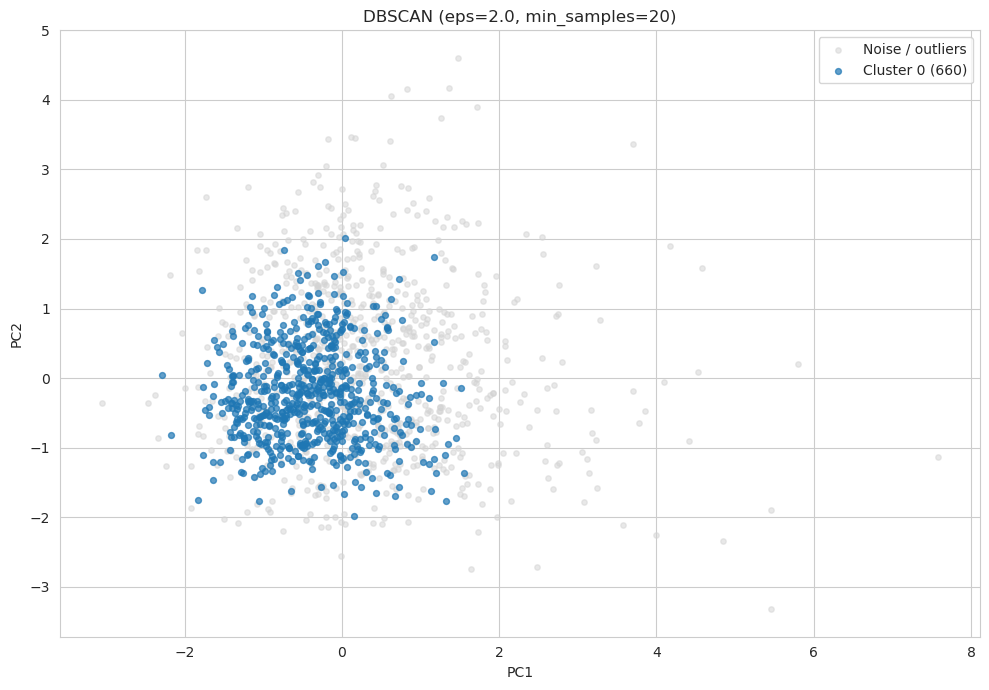

In [5]:
# DBSCAN on our customer data
db = DBSCAN(eps=2.0, min_samples=20)
labels_db = db.fit_predict(X_sample)

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = (labels_db == -1).sum()

print(f"DBSCAN found {n_clusters} clusters")
print(f"Points flagged as noise: {n_noise}  ({n_noise/len(labels_db):.1%})")
print()

# Visualise
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(X_2d_sample[labels_db == -1, 0], X_2d_sample[labels_db == -1, 1],
            s=15, color="lightgray", alpha=0.5, label="Noise / outliers")
unique_clusters = sorted([c for c in set(labels_db) if c != -1])
for c in unique_clusters:
    mask = labels_db == c
    ax.scatter(X_2d_sample[mask, 0], X_2d_sample[mask, 1],
                s=18, alpha=0.7, label=f"Cluster {c} ({mask.sum()})")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title(f"DBSCAN (eps=2.0, min_samples=20)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

### 💡 What you should notice

- DBSCAN may merge points K-Means would split, or split points K-Means would merge.
- The number of clusters is DATA-DRIVEN — not specified by you.
- The noise category gives you outlier detection for free.

### Tuning `eps` — the k-distance plot

Standard heuristic: plot the distance to the `min_samples`-th nearest neighbour for every point. The "elbow" in the sorted curve suggests a good `eps`.

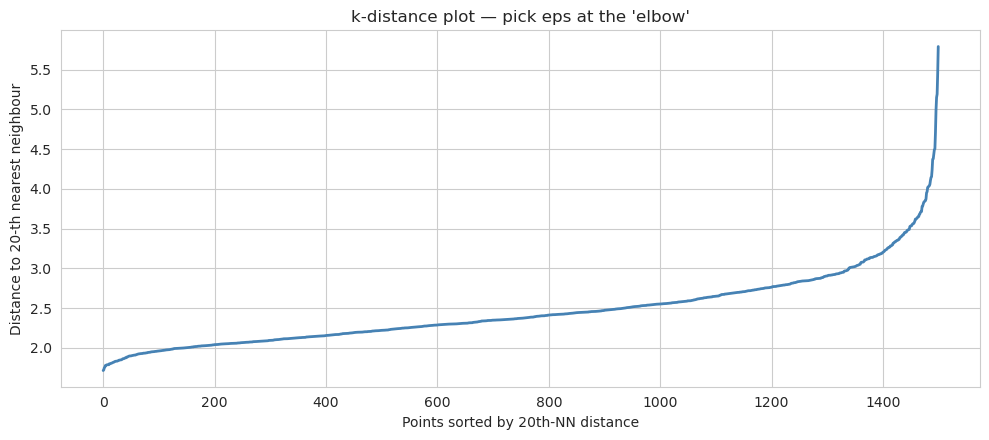

Look for the bend in the curve. That's where 'normal' density transitions to 'low' density.
For our data, somewhere around eps=2-3 looks right.


In [6]:
from sklearn.neighbors import NearestNeighbors

min_samples = 20
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_sample)
distances, _ = nn.kneighbors(X_sample)
k_distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(k_distances, linewidth=2, color="steelblue")
ax.set_xlabel("Points sorted by 20th-NN distance")
ax.set_ylabel(f"Distance to {min_samples}-th nearest neighbour")
ax.set_title("k-distance plot — pick eps at the 'elbow'")
plt.tight_layout()
plt.show()
print("Look for the bend in the curve. That's where 'normal' density transitions to 'low' density.")
print("For our data, somewhere around eps=2-3 looks right.")

# 3. UMAP — Non-Linear Visualisation

UMAP (Uniform Manifold Approximation and Projection) is the modern alternative to t-SNE for non-linear dimensionality reduction. Faster, scales better, often produces more interpretable layouts.

In [7]:
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("UMAP not installed. Run: pip install umap-learn")

if HAS_UMAP:
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    X_umap = reducer.fit_transform(X_sample)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].scatter(X_2d_sample[:, 0], X_2d_sample[:, 1], alpha=0.4, s=12, color="steelblue")
    axes[0].set_title("PCA — first 2 components")
    axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

    axes[1].scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.4, s=12, color="coral")
    axes[1].set_title("UMAP 2D embedding")
    axes[1].set_xlabel("UMAP dim 1"); axes[1].set_ylabel("UMAP dim 2")
    plt.tight_layout()
    plt.show()

    print("UMAP often reveals structure that PCA's linear projection misses.")
    print("Use UMAP for visualisation. Use PCA for preprocessing (downstream models).")
else:
    print("Install UMAP and re-run this cell:  pip install umap-learn")

UMAP not installed. Run: pip install umap-learn
Install UMAP and re-run this cell:  pip install umap-learn


## Choosing between methods — quick guide

| Method | Best for | Pros | Cons |
|---|---|---|---|
| **K-Means** | Customer segmentation, "give me K groups" | Fast, scalable, interpretable | Assumes spherical clusters; needs K |
| **Hierarchical** | When you want to see ALL K values at once | Dendrogram visualisation | O(n²) — slow on large data |
| **DBSCAN** | Non-globular clusters; data with outliers | No K required; finds outliers | Needs eps tuning; varying densities |
| **PCA** | Visualisation + preprocessing | Fast, interpretable, linear | Captures only linear structure |
| **UMAP / t-SNE** | Visualisation when PCA looks flat | Reveals non-linear structure | Slow; not suitable for preprocessing |

For most tabular business data: **K-Means + PCA for everyday work, DBSCAN when shapes are weird, UMAP when you need a really clean visualisation for a slide.